# GB  on sequence on more position effects, GC; K-mer
Minimal, readable pipeline split into cells.

In [1]:
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 18
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 18


## 1) Imports & config

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
try:
    from scipy.interpolate import PchipInterpolator
    _HAVE_PCHIP = True
except Exception:
    _HAVE_PCHIP = False

INFILE = "merged_output_13infile.csv"   # must contain columns: sequence, LogGFP
SEQ_COL = "sequence"
LABEL_COL = "LogGFP"
WINDOW = ("span", 5, 23)                  # ("all",0,0) or ("span", start, end)
TEST_SIZE = 0.20
SEED = 123
OUT = "seq_rf"

from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=1000,
    random_state=123
)
# hgb.fit(Xtr, ytr)  # <-- comment this until Xtr, ytr exist




onehot_positional	Converts each DNA sequence into a one-hot encoded numeric array (mononucleotide level)	DataFrame of 0s and 1s
Model trains on:	The frequency/pattern of each nucleotide (A/C/G/T) at each specific positio.Global features (cheap, effective):
GC fraction
length
longest poly-A and poly-T run (captures homopolymers)
k-mer features (richer sequence context):
Frequencies of observed k-mers for chosen k (e.g., 2 or 3)
Normalized by the number of windows (len(seq) - k + 1

In [3]:
def build_X(
    df: pd.DataFrame,
    window=WINDOW,          # ("all",0,0) or ("span", start, end)
    kmer_ks=(2,3),
    collapse_rc=True,
    add_global=True
) -> pd.DataFrame:
    import numpy as np, pandas as pd
    from itertools import product

    NUCS = "ACGT"
    seqs = df[SEQ_COL].astype(str).str.upper().str.replace("U","T", regex=False)
    seqs = seqs.map(lambda s: ''.join(ch for ch in s if ch in NUCS))

    # window
    if window[0] == "all":
        L = seqs.str.len().min()
        start, end = 0, L-1
    else:
        _, start, end = window

    # positional mono one-hot
    cols = [f"pos{p}_{n}" for p in range(start, end+1) for n in NUCS]
    Xpos = np.zeros((len(seqs), (end-start+1)*4), float)
    for i,s in enumerate(seqs):
        s = (s + "N"*(end+1-len(s)))[:end+1]
        for p in range(start, end+1):
            b = s[p]
            if b in NUCS:
                Xpos[i, (p-start)*4 + NUCS.index(b)] = 1.0
    frames = [pd.DataFrame(Xpos, columns=cols, index=df.index)]

    # globals
    if add_global:
        def longest_run(s, base):
            m = c = 0
            for ch in s:
                if ch == base: c += 1; m = max(m,c)
                else: c = 0
            return m
        g = pd.DataFrame(index=df.index)
        g["gc_frac"]   = seqs.map(lambda s: 0.0 if len(s)==0 else (s.count("G")+s.count("C"))/len(s))
        g["length"]    = seqs.map(len)
        g["max_polyA"] = seqs.map(lambda s: longest_run(s,"A"))
        g["max_polyT"] = seqs.map(lambda s: longest_run(s,"T"))
        frames.append(g)

    # k-mer freqs
    if kmer_ks:
        def rc(s): return s.translate(str.maketrans("ACGT","TGCA"))[::-1]
        vocab = []
        for k in kmer_ks:
            base = [''.join(t) for t in product(NUCS, repeat=k)]
            if collapse_rc:
                seen=set(); kept=[]
                seen=set(); kept=[]
                for km in base:
                    key = min(km, rc(km))
                    if key not in seen: seen.add(key); kept.append(key)
                base = kept
            vocab += [(k, km) for km in base]
        mat = np.zeros((len(seqs), len(vocab)), float)
        for i,s in enumerate(seqs):
            for j,(k,km) in enumerate(vocab):
                if len(s) >= k:
                    denom = len(s) - k + 1
                    mat[i,j] = sum(1 for t in range(denom) if s[t:t+k]==km)/denom
        frames.append(pd.DataFrame(mat, columns=[f"{k}mer_{km}" for k,km in vocab], index=df.index))

    # no imputer/variance filter here
    return pd.concat(frames, axis=1)


2) Split → train-only filtering + imputation

3) Weights + fit (asymmetric tails)

chosen model to rf so the rest of your notebook keeps working without edits. Even if it’s a booster, rf = est is fine.

## 4) Train, calibrate, evaluate

In [4]:
# ---------- drop-in: clean split + weights + no-leak calibration ----------

from sklearn.model_selection import train_test_split, KFold
from sklearn.isotonic import IsotonicRegression
from sklearn.impute import SimpleImputer
import numpy as np, pandas as pd

# 1) Load & filter
df = pd.read_csv(INFILE)
#df = pd.read_csv("merged_output_balanced.csv")
df = df[df[LABEL_COL] > 1.2].reset_index(drop=True)

# 2) Features (ensure build_X does NOT impute; we impute AFTER the split)
X = build_X(df)
y = pd.to_numeric(df[LABEL_COL], errors="coerce").to_numpy()

# 3) Make 20-bin quantile strata (safe fallback if qcut errors)
def make_strata(y, Q=20):
    for q in range(Q, 5, -1):  # try 20 down to 6
        try:
            return pd.qcut(pd.Series(y), q=q, labels=False, duplicates="drop")
        except Exception:
            continue
    return None

bins = make_strata(y, Q=20)

# 4) 80/20 split (stratified if bins worked)
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED,
    stratify=bins if bins is not None else None
)
# 6) Compute sample weights (optional, for asymmetric tails)
def make_weights(y, lower_thr=1.5, upper_thr=2.5, low_w=1.5, high_w=2.0):
    """Return higher weights for low and high tails of y."""
    w = np.ones_like(y, float)
    w[y < lower_thr] *= low_w
    w[y > upper_thr] *= high_w
    return w

wtr = make_weights(ytr)




# ---- Gradient Boosting instead of Random Forest ----
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

est = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=6,
    max_iter=1000,
    random_state=SEED,
)

# fit (with weights if your sklearn version supports it)
try:
    est.fit(Xtr, ytr, sample_weight=wtr)
except TypeError:
    # older sklearn: no sample_weight support; fall back to unweighted fit
    est.fit(Xtr, ytr)

print("Train R² (HGB):", r2_score(ytr, est.predict(Xtr)))

# keep downstream variable name the same so the rest of your notebook works
rf = est



Train R² (HGB): 0.8602360884935891


## 5) Plots & saving predictions

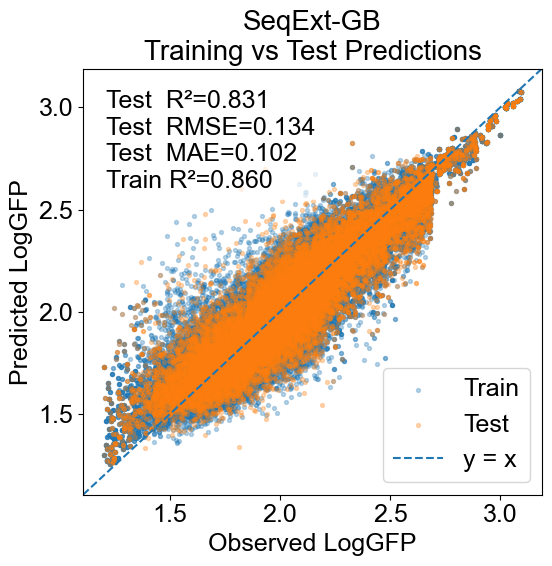

Saved figure -> rf_train_vs_test.png


In [5]:
# ---------- Plot: Training vs Test Predictions ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def plot_train_test_scatter(estimator, Xtr, ytr, Xte, yte, label_name="LogGFP",
                            title="RF — Training vs Test Predictions",
                            out_png="rf_train_vs_test.png",
                            calibrate=None):
    """
    calibrate: None (no calibration) or a fitted calibrator with .predict()
               e.g., an IsotonicRegression fitted on (yhat_tr, ytr)
    """
    # explicit, fresh preds
    yhat_tr = estimator.predict(Xtr)
    yhat_te_feature = estimator.predict(Xte)

    if calibrate is not None:
        yhat_tr = calibrate.predict(yhat_tr)
        yhat_te_feature = calibrate.predict(yhat_te_feature)

    # metrics
    r2_tr  = r2_score(ytr, yhat_tr)
    r2_te  = r2_score(yte, yhat_te_feature)
    mae_te = mean_absolute_error(yte, yhat_te_feature)
    rmse_te = mean_squared_error(yte, yhat_te_feature) ** 0.5

    # limits
    y_all = np.concatenate([ytr, yte])
    yhat_all = np.concatenate([yhat_tr, yhat_te_feature])
    lo = float(min(y_all.min(), yhat_all.min()))
    hi = float(max(y_all.max(), yhat_all.max()))
    pad = 0.05 * (hi - lo) if hi > lo else 0.1
    lo, hi = lo - pad, hi + pad

    # plot
    plt.figure(figsize=(6, 6))
    plt.scatter(ytr, yhat_tr, s=8, alpha=0.3, label="Train")
    plt.scatter(yte, yhat_te_feature, s=8, alpha=0.3, label="Test")
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, label="y = x")  # 45° ref

    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.xlabel(f"Observed {label_name}")
    plt.ylabel(f"Predicted {label_name}")
    plt.title(title)
    plt.legend()

    # annotate metrics (test)
    txt = f"Test  R²={r2_te:.3f}\nTest  RMSE={rmse_te:.3f}\nTest  MAE={mae_te:.3f}\nTrain R²={r2_tr:.3f}"
    plt.gca().text(0.05, 0.95, txt, transform=plt.gca().transAxes,
                   va="top", ha="left", bbox=dict(boxstyle="round", fc="white", alpha=0.7, ec="none"))

    plt.tight_layout()
    plt.savefig("HistGradientBoostingRegressor —sequence-more features-Training vs Test Predictions— Training vs Test Predictions.png", dpi=600, bbox_inches="tight")
    plt.savefig(
    " HistGradientBoostingRegressor —sequence-more features-Trainingvs Test Predictions.pdf",
    bbox_inches="tight")
    plt.show()
    print(f"Saved figure -> {out_png}")

# --- use it (no calibration) ---
plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
                        title="SeqExt-GB\n""Training vs Test Predictions")

# --- if you have an isotonic calibrator 'iso' fitted on (rf.predict(Xtr), ytr) ---
# plot_train_test_scatter(rf, Xtr, ytr, Xte, yte, label_name="LogGFP",
#                         title="RF (Calibrated) — Training vs Test Predictions",
#                         out_png="rf_train_vs_test_cal.png",
#                         calibrate=iso)


In [6]:
# --- Prepare predictions if not already defined ---
try:
    yhat_te_seq
except NameError:
    # if calibrated predictions exist:
    if 'calib' in locals():
        s_te = rf.predict(Xte)
        yhat_te_seq = apply_calibrator(s_te, calib)
    else:
        # otherwise just use raw predictions
        yhat_te_seq = rf.predict(Xte)
        
        pd.DataFrame({"yte": yte, "yhat_te_seq": yhat_te_seq}).to_csv("seq_model_results.csv", index=False)


Blue points (Train): predictions on your training data (ytr vs yhat_tr)
Orange points (Test): predictions on your held-out test data (yte vs yhat)
Red dashed line: ideal line where Predicted = Observed

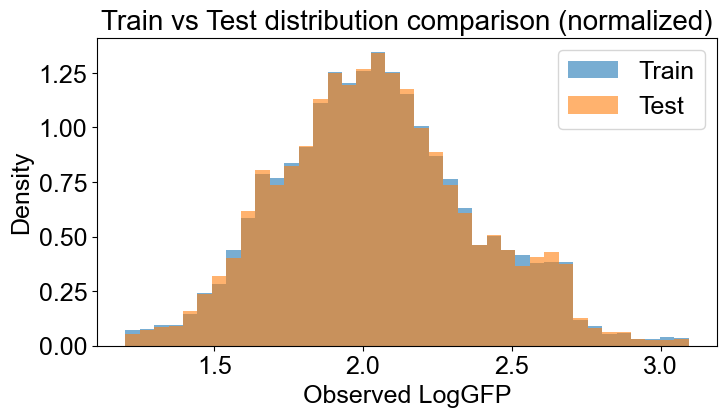

In [7]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(y.min(), y.max(), 40)  # same bins for both

plt.figure(figsize=(8, 4))
plt.hist(ytr, bins=bins, density=True, alpha=0.6, label="Train")
plt.hist(yte, bins=bins, density=True, alpha=0.6, label="Test")
plt.xlabel("Observed LogGFP")
plt.ylabel("Density")
plt.title("Train vs Test distribution comparison (normalized)")
plt.legend()
plt.show()


see the distribution

77874 19469 4.0
Middle counts 1.90–2.00: train= 9649 test= 2435


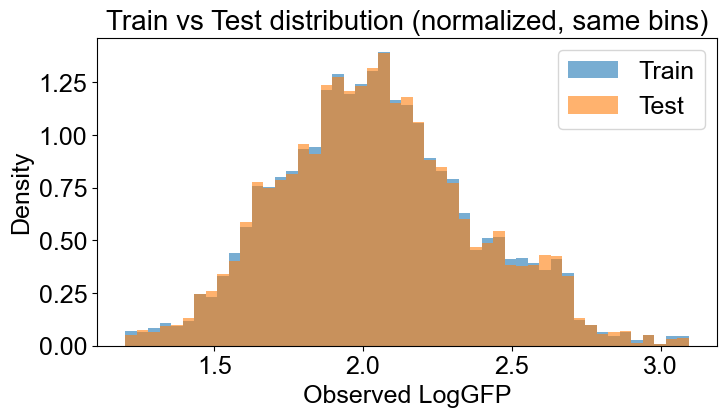

Train quantiles:
 0.0    1.201
0.1    1.640
0.2    1.766
0.3    1.870
0.4    1.951
0.5    2.031
0.6    2.105
0.7    2.197
0.8    2.314
0.9    2.506
1.0    3.094
dtype: float64

Test quantiles:
 0.0    1.201
0.1    1.640
0.2    1.766
0.3    1.870
0.4    1.950
0.5    2.031
0.6    2.106
0.7    2.197
0.8    2.313
0.9    2.505
1.0    3.094
dtype: float64


In [8]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# 1) Confirm sizes (should be ~80/20)
print(len(ytr), len(yte), round(len(ytr)/len(yte), 3))

# 2) Count samples in the “middle” band, e.g. 1.90–2.00
mid_mask_tr = (ytr >= 1.90) & (ytr <= 2.00)
mid_mask_te = (yte >= 1.90) & (yte <= 2.00)
print("Middle counts 1.90–2.00:",
      "train=", mid_mask_tr.sum(),
      "test=",  mid_mask_te.sum())

# 3) Compare shapes with SAME bins and density (so areas match)
bins = np.linspace(y.min(), y.max(), 50)
plt.figure(figsize=(8,4))
plt.hist(ytr, bins=bins, density=True, alpha=0.6, label="Train")
plt.hist(yte, bins=bins, density=True, alpha=0.6, label="Test")
plt.xlabel("Observed LogGFP"); plt.ylabel("Density")
plt.title("Train vs Test distribution (normalized, same bins)")
plt.legend(); plt.show()

# 4) Quantile table to see coverage across the range
qs = np.linspace(0,1,11)
print("Train quantiles:\n", pd.Series(ytr).quantile(qs).round(3))
print("\nTest quantiles:\n",  pd.Series(yte).quantile(qs).round(3))


save the model why that works all with the same rf code since I definded the booster downstrema as rf so that I could use my other code cells that I had built before

In [9]:
import joblib, json, time

# Safely grab things from the current kernel, defaulting to None when missing
CALIBRATOR     = locals().get("calib", None)            # e.g., ("iso", iso_model) or None
SEQ_FEATURIZER = locals().get("seq_featurizer", None)   # your featurizer or None

# Required bits — assert so you get a clear message if something is missing
rf        = locals().get("rf", None)        # trained regressor
imp       = locals().get("imp", None)       # SimpleImputer or None
Xtr       = locals().get("Xtr", None)       # training features DataFrame
SEQ_COL   = locals().get("SEQ_COL", "sequence")
LABEL_COL = locals().get("LABEL_COL", "logGFP")
SEED      = locals().get("SEED", 42)

assert rf  is not None,  "rf (trained model) is not defined"
assert Xtr is not None,  "Xtr (training features) is not defined"

bundle = {
    "version": "seq_rf_v1",
    "trained_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "label_col": LABEL_COL,
    "seq_col":  SEQ_COL,
    "seed": SEED,
    "rf_params": getattr(rf, "get_params", lambda: {})(),

    # columns AFTER featurization/selection (what the model expects)
    "feature_columns": list(Xtr.columns),

    # preprocessing artifacts
    "imputer": imp,                 # may be None
    "calibrator": CALIBRATOR,       # may be None
    "featurizer": SEQ_FEATURIZER,   # may be None

    # the trained model
    "model": rf,
}
bundle["y_true_te"]       = yte
bundle["y_pred_te"]  = yhat_te_seq

joblib.dump(bundle, "seq_boost_model.joblib")
print("Saved: seq_boost_model.joblib")

# Lightweight metadata (no big objects)
meta = {
    k: (v if isinstance(v, (str,int,float,bool,tuple,list,dict)) else str(type(v)))
    for k,v in bundle.items()
    if k not in ["imputer","model","calibrator","featurizer"]
}
with open("seq_boost_model.meta.json","w") as f:
    json.dump(meta, f, indent=2)
print("Saved: seq_boost_model.meta.json")



Saved: seq_boost_model.joblib
Saved: seq_boost_model.meta.json


Minimal fix to get the plot

In [10]:
yhat_raw = rf.predict(Xte)
# If calibration not done yet:
try:
    yhat
except NameError:
    yhat = yhat_raw.copy()




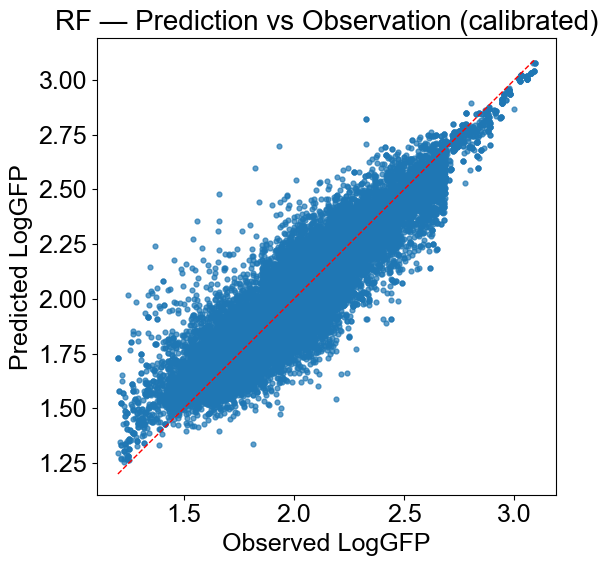

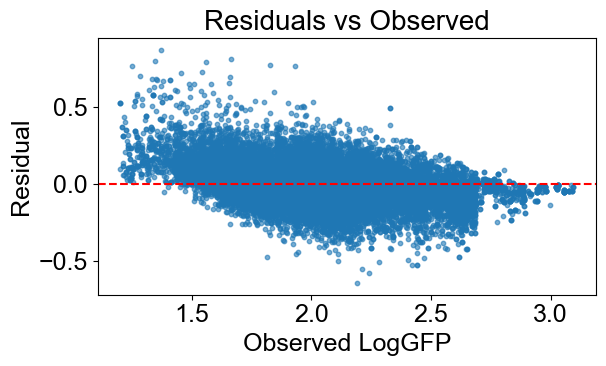

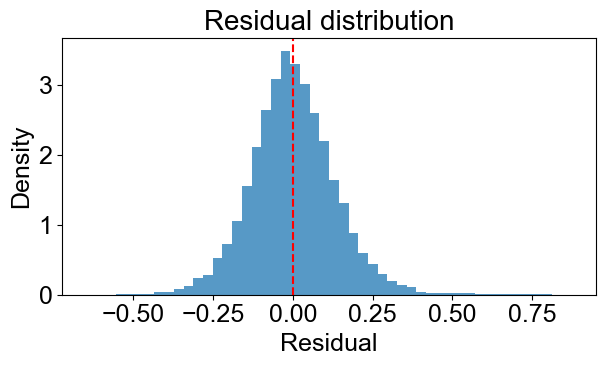

Mean residual: 0.0020256426472354053


In [11]:
def show_and_save(fig, name):
    fig.tight_layout(); fig.savefig(f"{OUT}_{name}.png", dpi=300); plt.show(); plt.close(fig)

fig = plt.figure(figsize=(6,6))
plt.scatter(yte, yhat, s=12, alpha=0.7)
lo,hi = float(min(yte.min(),yhat.min())), float(max(yte.max(),yhat.max()))
plt.plot([lo,hi],[lo,hi],'r--',lw=1)
plt.xlabel("Observed LogGFP"); plt.ylabel("Predicted LogGFP")
plt.title("RF — Prediction vs Observation (calibrated)")
show_and_save(fig, "pred_vs_obs")

res = yhat - yte
fig = plt.figure(figsize=(6.4,4))
plt.scatter(yte,res,s=10,alpha=0.6); plt.axhline(0, color='r', ls='--')
plt.xlabel("Observed LogGFP"); plt.ylabel("Residual")
plt.title("Residuals vs Observed")
show_and_save(fig, "residuals_vs_obs")

fig = plt.figure(figsize=(6.4,4))
plt.hist(res, bins=50, density=True, alpha=0.75)
plt.axvline(0, color='r', ls='--'); plt.xlabel("Residual"); plt.ylabel("Density")
plt.title("Residual distribution")
show_and_save(fig, "residual_hist")

pd.DataFrame({"y_true":yte, "y_pred_raw":yhat_raw, "y_pred":yhat}).to_csv(f"{OUT}_preds.csv", index=False)

bias = res.mean()
print("Mean residual:", bias)



Check joblib

In [12]:
import joblib
import numpy as np

B = joblib.load("seq_boost_model.joblib")

print("Keys in bundle:", B.keys())
y_true = B["y_true_te"]
y_pred = B["y_pred_te"]

print("Lengths:", len(y_true), len(y_pred))
print("First 5 pairs:")
for t, p in list(zip(y_true, y_pred))[:5]:
    print(f"  true={t:.3f}, pred={p:.3f}")

print("Feature columns:", len(B["feature_columns"]))
print(B["feature_columns"][:5])


Keys in bundle: dict_keys(['version', 'trained_at', 'label_col', 'seq_col', 'seed', 'rf_params', 'feature_columns', 'imputer', 'calibrator', 'featurizer', 'model', 'y_true_te', 'y_pred_te'])
Lengths: 19469 19469
First 5 pairs:
  true=2.709, pred=2.715
  true=1.886, pred=1.786
  true=2.202, pred=2.317
  true=2.093, pred=1.808
  true=2.186, pred=2.052
Feature columns: 122
['pos5_A', 'pos5_C', 'pos5_G', 'pos5_T', 'pos6_A']


prediction

In [13]:
import joblib, pandas as pd, numpy as np

# load saved model
B  = joblib.load("seq_boost_model.joblib")
rf = B["model"]
imp = B.get("imputer", None)

# --- calibrator: handle None / tuple / dict ---
cal = B.get("calibrator", None)
if cal is None:
    calib_name, calib_obj = None, None
elif isinstance(cal, tuple) and len(cal) == 2:
    calib_name, calib_obj = cal
elif isinstance(cal, dict) and {"xp","fp"} <= set(cal.keys()):
    calib_name, calib_obj = "qmap", cal
else:
    raise ValueError(f"Unrecognized calibrator format: {type(cal)}")

feature_cols = B["feature_columns"]

# load your new CSV with sequences
NEW_FILE = "All_Fasta_sequnes_constructed_features.csv"
df_new = pd.read_csv(NEW_FILE)

# rebuild features (same as training)
Xnew = build_X(
    df_new,
    window=B.get("window", ("span", 5, 23)),
    kmer_ks=B.get("kmer_ks", (2, 3)),
    collapse_rc=B.get("collapse_rc", True),
    add_global=True,
)

# align to training feature order
Xnew = Xnew.reindex(columns=feature_cols)
Xnew = Xnew.apply(pd.to_numeric, errors="coerce")

# impute if we saved an imputer; otherwise pass through
if imp is not None:
    Xnew_imp = pd.DataFrame(imp.transform(Xnew), columns=feature_cols, index=Xnew.index)
else:
    Xnew_imp = Xnew

# predict
y_raw = rf.predict(Xnew_imp).astype(float)

# calibrate if available
if calib_name == "iso":
    y_pred = calib_obj.predict(y_raw)
elif calib_name == "qmap":
    xp, fp = calib_obj["xp"], calib_obj["fp"]
    y_pred = np.interp(y_raw, xp, fp)
else:
    y_pred = y_raw  # no calibrator

# attach and save
out = df_new.copy()
out["LogGFP_pred"] = y_pred
out.to_csv("new_sequences_with_predictions.csv", index=False)
print("Saved: new_sequences_with_predictions.csv")


Saved: new_sequences_with_predictions.csv


the 6 bins, and then weakest and strongest sequnce

In [14]:
import pandas as pd
import numpy as np

# ===== 1) Input: set this to the file your previous step wrote =====
INFILE = "predictions_sequence.tsv"   # <- produced by the loader
# If you saved TSV instead, use: INFILE = "seq_predictions.tsv"

# Auto-detect separator
df = pd.read_csv(INFILE, sep=None, engine="python")

# ===== 2) Identify columns =====
score_candidates = ["prediction"]
seq_candidates   = ["sequence", "Sequence"]

score_col = next((c for c in score_candidates if c in df.columns), None)
seq_col   = next((c for c in seq_candidates   if c in df.columns), None)

assert score_col is not None, f"No prediction column found in {INFILE}. Tried {score_candidates}"
assert seq_col   is not None, f"No sequence column found in {INFILE}. Tried {seq_candidates}"

# Helper to add core19 safely
def add_core19(x: pd.DataFrame) -> pd.DataFrame:
    y = x.copy()
    y.loc[:, "core19"] = y[seq_col].astype(str).map(lambda s: s[4:-4] if len(s) >= 9 else s)
    return y

# ===== 3) Top 3 strongest =====
top3 = df.sort_values(score_col, ascending=False).head(3).copy()
top3 = add_core19(top3)
top3.to_csv("predictions_top3_4_sequence.tsv", sep="\t", index=False)

# ===== 4) Bottom 3 weakest =====
bottom3 = df.sort_values(score_col, ascending=True).head(3).copy()
bottom3 = add_core19(bottom3)
bottom3.to_csv("predictions_bottom3_4_sequence.tsv", sep="\t", index=False)

print("Wrote:")
print(" - predictions_top3_4_sequence.tsv     (strongest 3 overall)")
print(" - predictions_bottom3_4_sequence.tsv  (weakest 3 overall)")


FileNotFoundError: [Errno 2] No such file or directory: 'predictions_sequence.tsv'

In [ ]:
import pandas as pd

df = pd.read_csv("new_sequences_with_predictions.csv")

def lookup(seq):
    print(df.loc[df["sequence"] == seq, ["sequence", "LogGFP_pred"]])

lookup("AAGGCCTAAGACTATACAAATAAGGCT")


Empty DataFrame
Columns: [sequence, LogGFP_pred]
Index: []


In [ ]:
import pandas as pd

# ============================
# 1. Load BIG prediction file
# ============================

big = pd.read_csv("new_sequences_with_predictions.csv")  # comma-separated by default
big = big.rename(columns={
    "sequence": "full_seq",
    "LogGFP_pred": "prediction"
})

# Strip AAAG in front & GGCT at end
big["core19"] = (
    big["full_seq"]
    .str.replace("^AAAG", "", regex=True)
    .str.replace("GGCT$", "", regex=True)
)

# Ensure max length 19 (safety)
big["core19"] = big["core19"].str.slice(0, 19)

# Keep only needed columns
big = big[["core19", "prediction"]]


# ============================
# 2. Load SMALL file
# ============================
small = pd.read_csv("new_sequnces.csv")    # comma-separated
small = small[["seq"]]                            # keep only this column

# Preserve original order
small["order"] = range(len(small))


# ============================
# 3. Merge WITHOUT sorting by prediction
# ============================
merged = small.merge(
    big,
    left_on="seq",
    right_on="core19",
    how="left"
)

# Keep only seq + prediction
result = merged[["seq", "prediction", "order"]]

# Restore the original order of the small file
result = result.sort_values("order").drop(columns="order")


# ============================
# 4. Save
# ============================
result.to_csv("seq_and_predictions.tsv", sep="\t", index=False)

print("Saved: seq_and_predictions.tsv")
print(result.head())


FileNotFoundError: [Errno 2] No such file or directory: 'new_sequnces.csv'

In [21]:
import shap
import numpy as np
import matplotlib.pyplot as plt

Beeswarm

In [22]:
def make_shap_beeswarm_fast(model, X, title, top_k=5, savepath=None):
    explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")
    shap_values = explainer.shap_values(X, approximate=True)

    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

    mean_abs = np.abs(shap_vals).mean(axis=0)
    idx = np.argsort(mean_abs)[::-1][:top_k]

    X_top = X.iloc[:, idx]
    shap_top = shap_vals[:, idx]

    plt.figure(figsize=(5, 3.2))
    shap.summary_plot(
        shap_top,
        X_top,
        feature_names=X_top.columns.tolist(),
        max_display=top_k,
        plot_type="dot",
        show=False
    )
    plt.title(title, loc="left")
    plt.xlabel("SHAP value (impact on model output)")

    if savepath:
        plt.tight_layout()
        plt.savefig(savepath, dpi=300)

    plt.show()


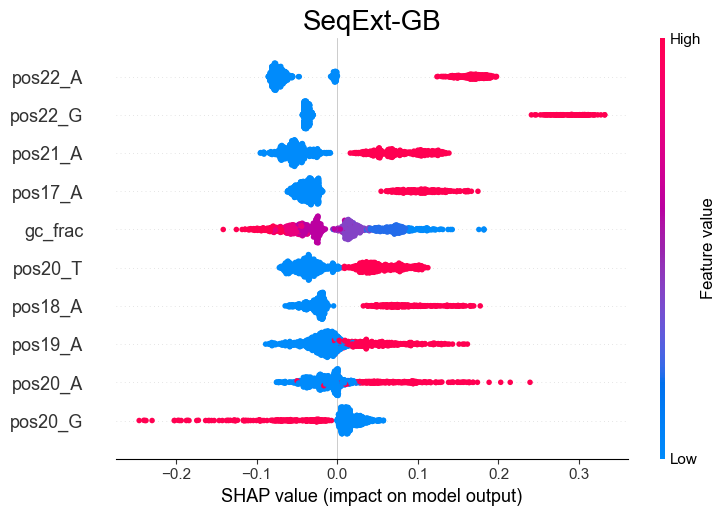

In [26]:
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

plt.close("all")

# --- Align features ---
if not isinstance(Xte, pd.DataFrame):
    Xte_df = pd.DataFrame(Xte, columns=rf.feature_names_in_)
else:
    Xte_df = Xte.copy()

Xte_df = Xte_df[rf.feature_names_in_]

# --- Subsample ---
n_sample = min(len(Xte_df), 1000)
Xte_df = Xte_df.sample(n_sample, random_state=42)

# --- SHAP ---
explainer = shap.TreeExplainer(rf, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(Xte_df, approximate=True)
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

# --- Top features ---
top_k = 10
mean_abs = np.abs(shap_vals).mean(axis=0)
idx = np.argsort(mean_abs)[::-1][:top_k]

X_top = Xte_df.iloc[:, idx]
shap_top = shap_vals[:, idx]

# --- Plot: same as your old working code ---
plt.figure(figsize=(5, 3.2))

shap.summary_plot(
    shap_top,
    X_top,
    feature_names=X_top.columns.tolist(),
    max_display=top_k,
    plot_type="dot",
    show=False
)

# --- Fade vertical zero line ---
ax = plt.gca()

for line in ax.lines:
    xdata = line.get_xdata()
    if len(xdata) == 2 and np.allclose(xdata, [0, 0]):
        line.set_alpha(0.7)
        line.set_linewidth(0.5)

plt.title("SeqExt-GB")
plt.xlabel("SHAP value (impact on model output)")
plt.tight_layout()

fig = plt.gcf()
fig.savefig("SeqExt-GB.pdf", bbox_inches="tight")

plt.show()
plt.close(fig)

Model prediction (LogGFP) for candidate: 2.5774253230809774


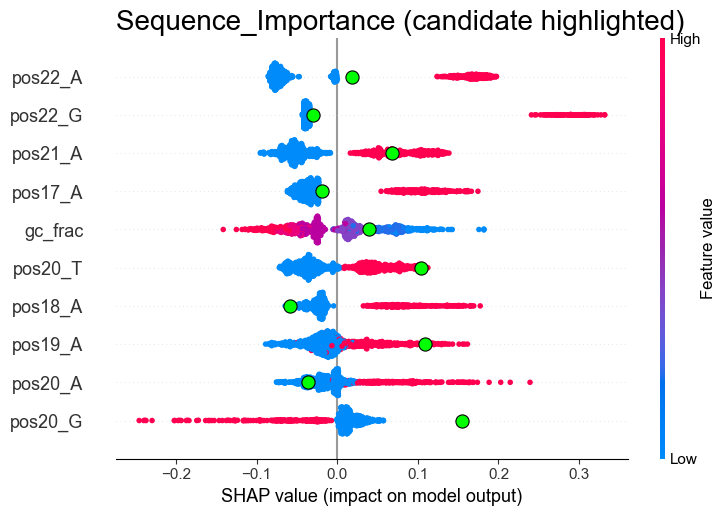

In [24]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import re
from collections import defaultdict

# ================== USER INPUT ==================
# 19-bp UP-element core of your designed sequence
my_core = "CCgcattaacgcgataaag"   # <-- change to your 19-mer

# Your trained SEQUENCE-BASED model and its test matrix
seq_model = rf      # random forest or booster trained on sequence features
Xte_seq   = Xte     # test (or train) data used to evaluate that model
# =================================================


# ---- 1. Helper: encode a 19-bp core into the sequence-model features ----
def encode_core19_for_seq_model(core19: str, feature_names) -> pd.DataFrame:
    """
    Build a 1-row DataFrame with the same columns as the sequence model expects.
    Assumes:
      - features named like pos6_A ... pos24_T
      - 2mer_XX k-mer counts
      - 3mer_XXX k-mer counts
    and that pos6..pos24 cover the 19 bp core (pos index -> core index = pos-6).
    """
    core = core19.upper()
    if len(core) != 19:
        raise ValueError(f"core19 must be length 19, got {len(core)}")

    # precompute di-/tri-nucleotide counts over the 19-mer
    di_counts  = defaultdict(int)
    tri_counts = defaultdict(int)
    for i in range(len(core) - 1):
        di = core[i:i+2]
        di_counts[di] += 1
    for i in range(len(core) - 2):
        tri = core[i:i+3]
        tri_counts[tri] += 1

    row = {}
    for f in feature_names:
        # position features: pos6_A etc.
        m = re.match(r"pos(\d+)_([ACGT])$", f)
        if m:
            pos  = int(m.group(1))     # e.g. 6..24
            base = m.group(2)
            idx  = pos - 6             # map pos6 -> core[0], pos24 -> core[18]
            if 0 <= idx < 19 and core[idx] == base:
                row[f] = 1.0
            else:
                row[f] = 0.0
            continue

        # 2-mer k-mer counts: 2mer_AC, 2mer_TG, ...
        if f.startswith("2mer_"):
            di = f[5:]
            row[f] = float(di_counts.get(di, 0))
            continue

        # 3-mer k-mer counts: 3mer_AAA, 3mer_CGT, ...
        if f.startswith("3mer_"):
            tri = f[5:]
            row[f] = float(tri_counts.get(tri, 0))
            continue

        # anything else -> default 0.0
        row[f] = 0.0

    # return as 1-row DataFrame with correct column order
    return pd.DataFrame([row], columns=feature_names)


# ---- 2. Prepare background matrix for SHAP (X_bg_seq) ----
if not isinstance(Xte_seq, pd.DataFrame):
    X_bg_seq = pd.DataFrame(Xte_seq, columns=seq_model.feature_names_in_)
else:
    X_bg_seq = Xte_seq.copy()

X_bg_seq = X_bg_seq[seq_model.feature_names_in_]
X_bg_seq = X_bg_seq.sample(min(len(X_bg_seq), 1000), random_state=42)

feature_names = seq_model.feature_names_in_

# ---- 3. Encode your 19-mer into model features ----
X_cand_seq = encode_core19_for_seq_model(my_core, feature_names)

# model prediction for this design
y_pred_cand_seq = seq_model.predict(X_cand_seq)
print("Model prediction (LogGFP) for candidate:",
      float(np.array(y_pred_cand_seq).ravel()[0]))


# ---- 4. Build SHAP explainer and compute SHAP values ----
explainer = shap.TreeExplainer(seq_model, feature_perturbation="tree_path_dependent")

shap_bg = explainer.shap_values(X_bg_seq, approximate=True)
shap_bg_vals = shap_bg[1] if isinstance(shap_bg, list) else shap_bg

shap_cand = explainer.shap_values(X_cand_seq, approximate=True)
shap_cand_vals = shap_cand[1] if isinstance(shap_cand, list) else shap_cand  # (1, n_features)


# ---- 5. Take top-k most important features and plot beeswarm ----
top_k = 10
mean_abs = np.abs(shap_bg_vals).mean(axis=0)
idx = np.argsort(mean_abs)[::-1][:top_k]

X_top_bg      = X_bg_seq.iloc[:, idx]
shap_top_bg   = shap_bg_vals[:, idx]
shap_top_cand = shap_cand_vals[:, idx]   # (1, top_k)

plt.figure(figsize=(5, 3.2))
shap.summary_plot(
    shap_top_bg,
    X_top_bg,
    feature_names=X_top_bg.columns.tolist(),
    max_display=top_k,
    plot_type="dot",
    show=False
)
plt.title("Sequence_Importance (candidate highlighted)", loc="left")
plt.xlabel("SHAP value (impact on model output)")

# overlay green dot for your candidate
for y_idx in range(top_k):
    x = shap_top_cand[0, y_idx]
    plt.scatter(
        x, y_idx,
        s=90,
        facecolor="lime",
        edgecolor="black",
        linewidth=0.8,
        zorder=10,
    )

plt.tight_layout()
plt.show()
